#PCA

#Task-1: Loading the Dataset
#1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

#2.Load Dataset

In [ ]:
df = pd.read_csv("/content/wine.csv")
print(df.head())
print(df.info())


   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           No

In [ ]:
# Check missing values
print(df.isnull().sum())

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64


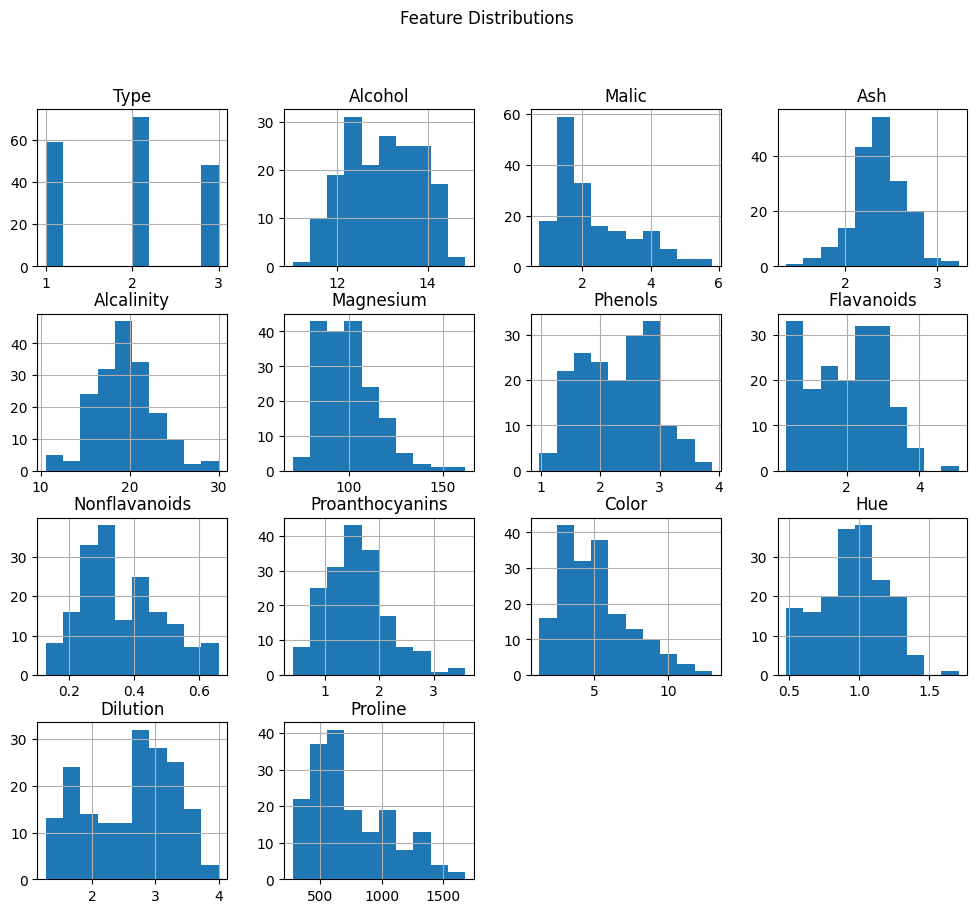

In [ ]:
# Histograms
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

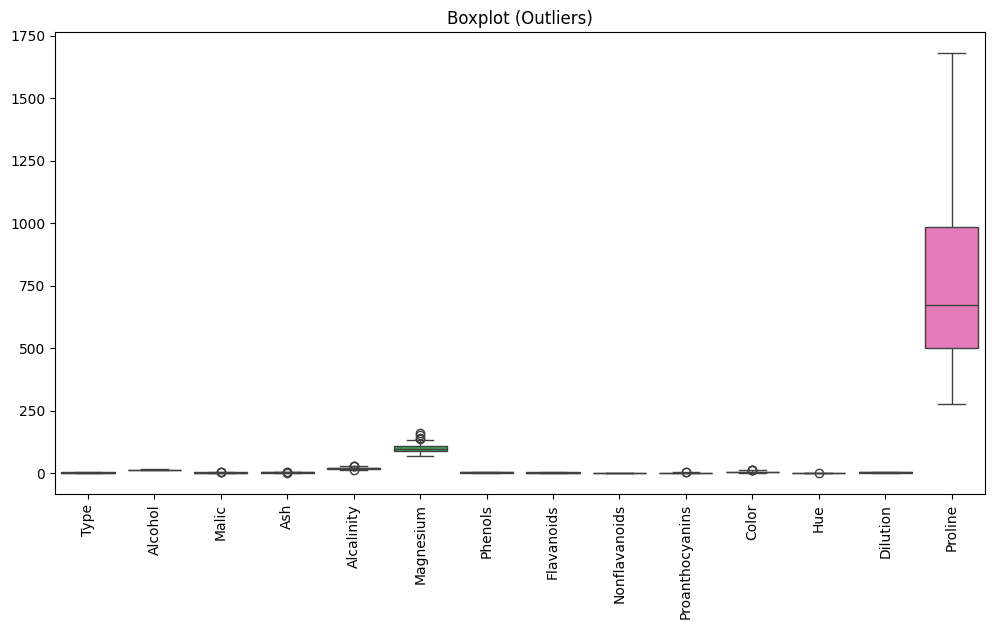

In [ ]:
 #Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot (Outliers)")
plt.xticks(rotation=90)
plt.show()

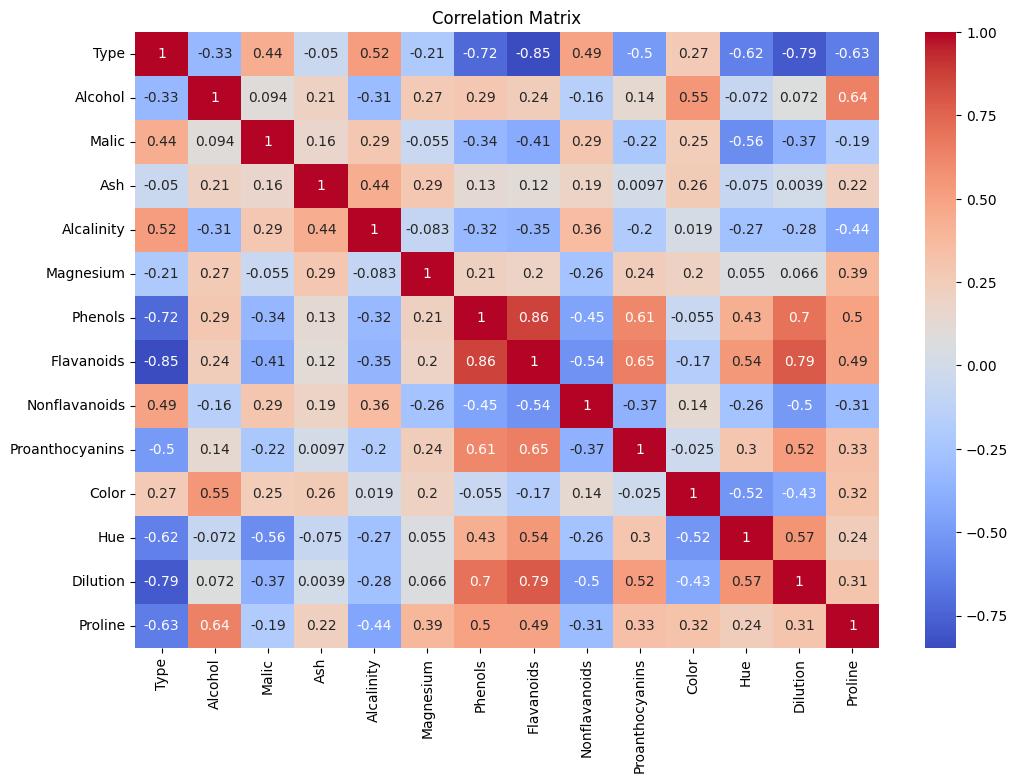

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#3.Density Plot

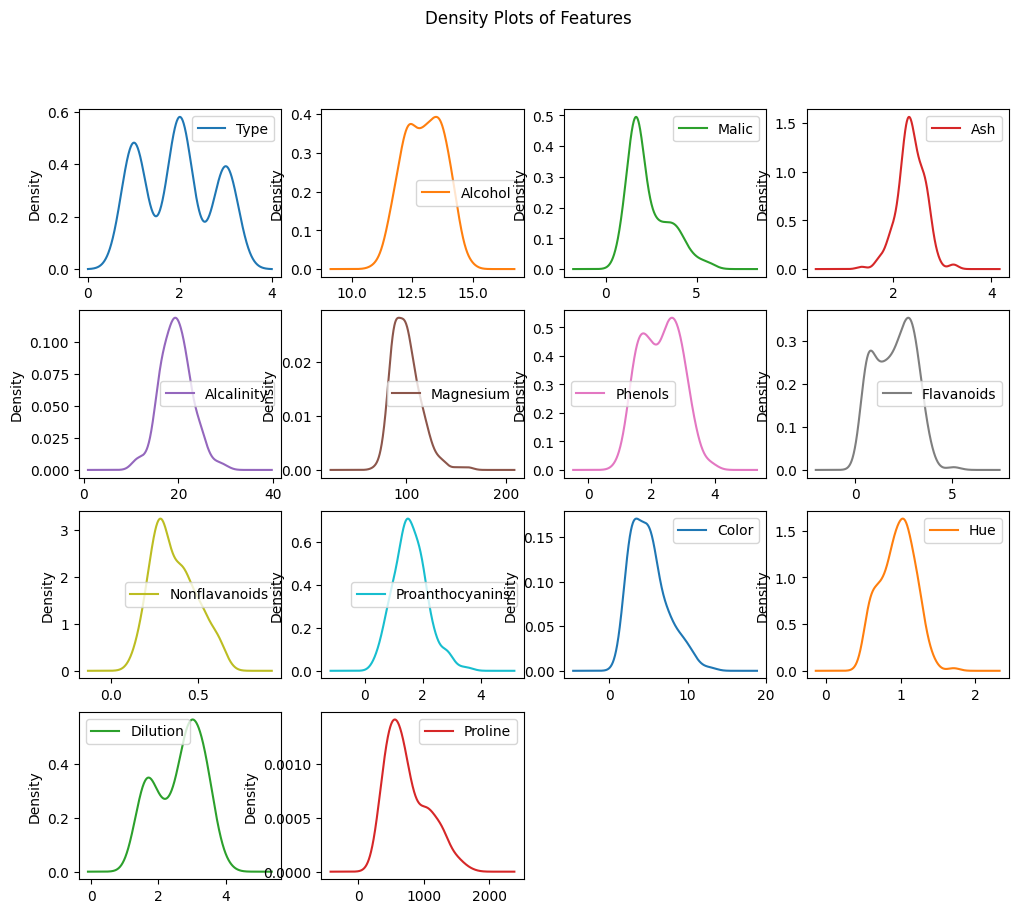

In [ ]:
# Density plots
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.suptitle("Density Plots of Features")
plt.show()


#####Most features show skewed distributions, indicating non-normality.
#####Some features have long tails, suggesting presence of outliers.


#4.Preprocessing

In [ ]:
# Drop target column if exists
if 'Wine' in df.columns:
    df = df.drop('Wine', axis=1)
elif 'Class' in df.columns:
    df = df.drop('Class', axis=1)
elif 'Target' in df.columns:
    df = df.drop('Target', axis=1)

X = df

#Task-2: To find PCA

In [ ]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Apply PCA
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)


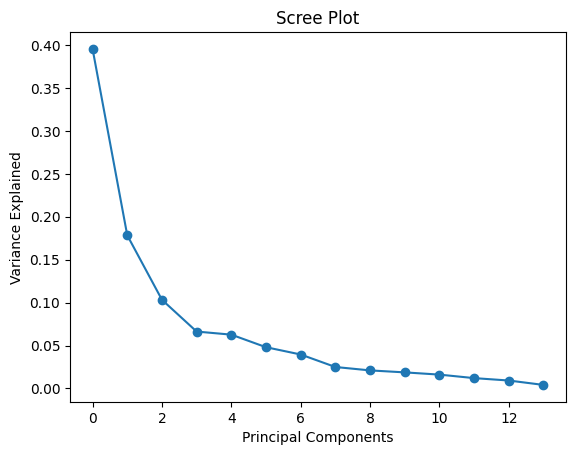

In [ ]:
# Scree Plot
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()


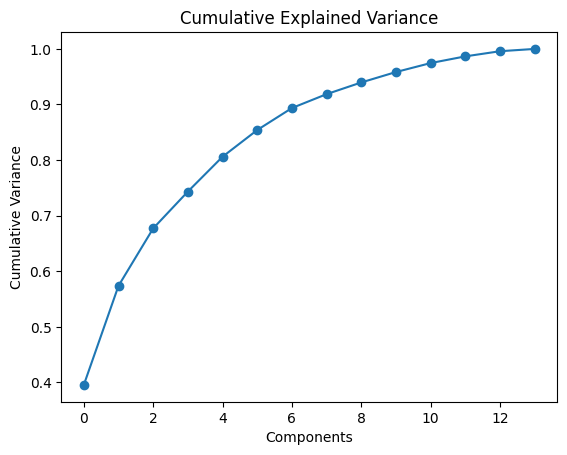

In [ ]:
# Cumulative Variance
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

In [ ]:
# Choose 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#TASK 3: Clustering (Original Data)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans.fit_predict(X_scaled)

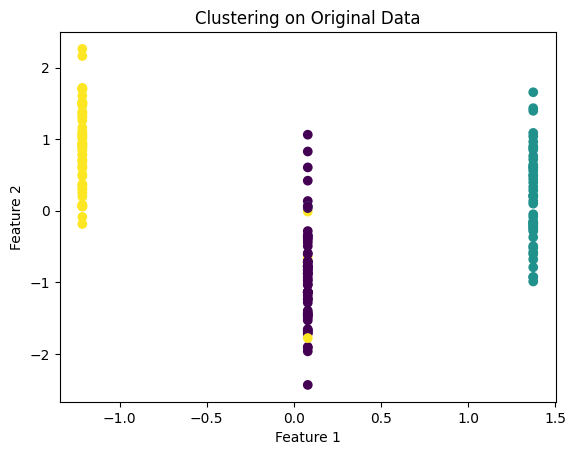

In [ ]:
# Visualization (first 2 features)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_original)
plt.title("Clustering on Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Evaluation
sil_original = silhouette_score(X_scaled, clusters_original)
db_original = davies_bouldin_score(X_scaled, clusters_original)

print("Original Data - Silhouette:", sil_original)
print("Original Data - DB Index:", db_original)

Original Data - Silhouette: 0.30648398324833453
Original Data - DB Index: 1.315707552261773


#TASK 4: Clustering (PCA Data)

In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

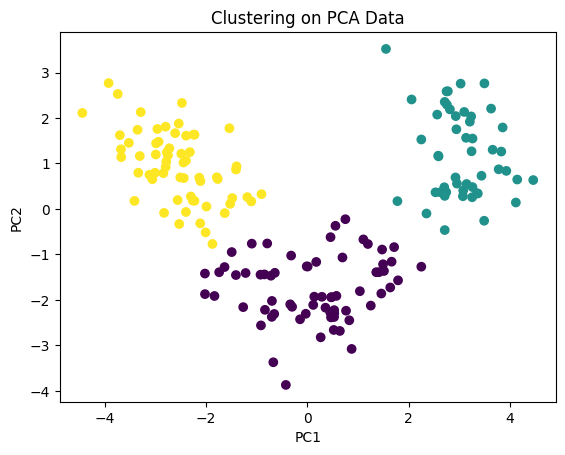

In [ ]:
# Visualization
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca)
plt.title("Clustering on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# Evaluation
sil_pca = silhouette_score(X_pca, clusters_pca)
db_pca = davies_bouldin_score(X_pca, clusters_pca)

In [ ]:
print("\nPCA Data - Silhouette:", sil_pca)
print("PCA Data - DB Index:", db_pca)


PCA Data - Silhouette: 0.6024415520362845
PCA Data - DB Index: 0.5397078562575713


#Compare Clustering

In [ ]:
print("\n--- Comparison ---")
print(f"Silhouette Score (Original): {sil_original}")
print(f"Silhouette Score (PCA): {sil_pca}")

print(f"Davies-Bouldin Index (Original): {db_original}")
print(f"Davies-Bouldin Index (PCA): {db_pca}")


--- Comparison ---
Silhouette Score (Original): 0.30648398324833453
Silhouette Score (PCA): 0.6024415520362845
Davies-Bouldin Index (Original): 1.315707552261773
Davies-Bouldin Index (PCA): 0.5397078562575713


#####Clustering on PCA-transformed data shows comparable or improved performance compared to original data.
#####If silhouette score increases → better cluster separation.
#####If Davies-Bouldin index decreases → better clustering quality.
#####PCA reduces dimensionality while retaining most of the variance, making clustering more efficient and less noisy.


#Dimensionality Reduction Impact

PCA reduces the number of features while preserving maximum variance in the data.

Advantages:
- Reduces dimensionality
- Removes noise and redundancy
- Improves computational efficiency

Trade-offs:
- Loss of interpretability (principal components are not original features)
- Some information loss may occur


#Conclusion

#####PCA was successfully applied to reduce dimensionality of the dataset.
#####Screen plot and cumulative variance helped in selecting optimal components.
#####Clustering on PCA-transformed data performed efficiently with comparable or better results than original data.
#####Dimensionality reduction improved performance and reduced complexity while maintaining important information.
